# Variational Monte Carlo

Executable companion to chapter 13.

Chapter 12 assembled the tools and ended with a first variational Monte Carlo
run.  This is the method proper: the variational principle, the trial wave
function and why it has the form it does, the local energy, the sampler, and
finally importance sampling with the quantum force.

The system is the two-electron quantum dot of chapter 11, which is small
enough to differentiate by hand, has the analytic answer $E = 3$ at
$\hbar\omega = 1$, and has already been solved by Hartree-Fock, MP2 and CCSD —
so the Monte Carlo result can be put on the same scale.

In [1]:
import sys
sys.path.insert(0, "../BookManybody/BookMaterial/Programs")

import math
import numpy as np
import matplotlib.pyplot as plt

import vmc

## 1. The trial function

$$
\Psi_T(\bm r_1,\bm r_2;\alpha,\beta)
 = \exp\!\left(-\frac{\alpha\omega}{2}(r_1^2+r_2^2)\right)
   \exp\!\left(\frac{r_{12}}{1+\beta r_{12}}\right)
$$

Two variational parameters: $\alpha$ scales the orbital, $\beta$ sets the
range of the correlation factor.  The numerator of the Jastrow exponent is
**not** a parameter — it is fixed at 1 by the cusp condition.

Both the local energy and the quantum force are differentiated by hand.  An
error in the first gives a wrong energy; an error in the second is *silent*.
So both get checked against finite differences before anything is run.

In [2]:
rng = np.random.default_rng(1)
worst_energy = worst_force = 0.0
for omega in (0.5, 1.0, 2.0):
    for _ in range(15):
        r = rng.normal(0.0, 1.0, (2, 2))
        for alpha, beta in ((0.98, 0.40), (0.80, 0.20), (1.10, 0.60)):
            worst_energy = max(worst_energy,
                abs(vmc.local_energy(r, alpha, beta, omega)
                    - vmc.local_energy_fd(r, alpha, beta, omega)))
            worst_force = max(worst_force, float(np.abs(
                vmc.quantum_force(r, alpha, beta, omega)
                - vmc.quantum_force_fd(r, alpha, beta, omega)).max()))
print(f"local energy : largest discrepancy {worst_energy:.1e}")
print(f"quantum force: largest discrepancy {worst_force:.1e}")
print("(both at the level of the finite-difference truncation error)")

local energy : largest discrepancy 5.1e-05
quantum force: largest discrepancy 2.7e-10
(both at the level of the finite-difference truncation error)


## 2. The cusp condition at work

As the electrons approach, $1/r_{12}$ diverges.  The Jastrow factor makes the
kinetic term produce a compensating divergence, and the local energy stays
finite.  That cancellation *is* the cusp condition.

     r_12   E_L with Jastrow    E_L without
   1.0000           3.031237           3.00
   0.1000           2.703286          12.00
   0.0100           2.611464         102.00
   0.0010           2.601159        1002.00
   0.0001           2.600116       10002.00


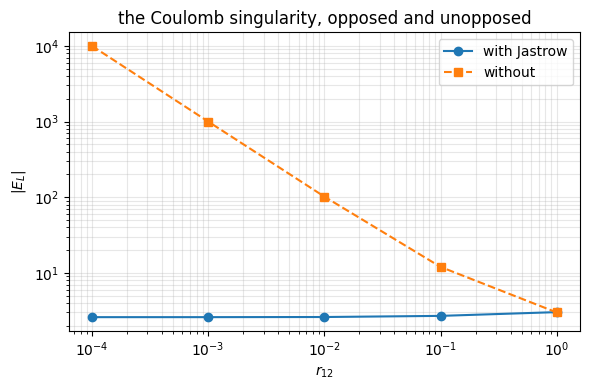

In [3]:
separations = np.array([1.0, 0.1, 0.01, 0.001, 0.0001])
with_jastrow, without = [], []
for r12 in separations:
    r = np.array([[r12/2, 0.0], [-r12/2, 0.0]])
    with_jastrow.append(vmc.local_energy(r, 1.0, 0.4))
    without.append(2.0 + 1.0/r12)

print(f"{'r_12':>9s} {'E_L with Jastrow':>18s} {'E_L without':>14s}")
for r12, a, b in zip(separations, with_jastrow, without):
    print(f"{r12:9.4f} {a:18.6f} {b:14.2f}")

plt.figure(figsize=(6, 4))
plt.loglog(separations, np.abs(with_jastrow), "o-", label="with Jastrow")
plt.loglog(separations, without, "s--", label="without")
plt.xlabel("$r_{12}$"); plt.ylabel("$|E_L|$")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("the Coulomb singularity, opposed and unopposed")
plt.tight_layout(); plt.show()

## 3. Brute-force Metropolis

Uniform proposals, one particle at a time, accepted with
$\min(1, |\Psi_T(y)|^2/|\Psi_T(x)|^2)$.

Two details are easy to get wrong: move **one** particle at a time (moving all
of them lowers the acceptance rate for the same step), and **count rejected
moves** — the old configuration is measured again.  Dropping them biases the
average.

In [4]:
steps = (0.5, 1.0, 2.0, 4.0, 8.0)
brute = {}
print(f"{'step':>6s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'variance':>10s} {'tau':>7s}")
for step in steps:
    r = vmc.vmc_brute_force(0.98, 0.40, n_cycles=20000, step=step,
                            rng=np.random.default_rng(2024))
    brute[step] = r
    print(f"{step:6.1f} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['variance']:10.5f} {r['tau']:7.2f}")

  step  acceptance        energy      error   variance     tau


   0.5      90.2%      2.999367   0.001400    0.00186   21.06


   1.0      80.2%      2.999729   0.000756    0.00197    5.79


   2.0      62.2%      3.000874   0.000503    0.00185    2.74


   4.0      35.2%      2.999744   0.000456    0.00190    2.18


   8.0      11.6%      3.000497   0.000811    0.00179    7.35


## 4. Importance sampling

The uniform proposal is wasteful: it offers moves in every direction equally,
including into regions where $|\Psi_T|^2$ is negligible.  Requiring the
Fokker-Planck equation to have $|\Psi_T|^2$ as its stationary solution forces
the drift to be the **quantum force**

$$
\bm F = \frac{2}{\Psi_T}\nabla\Psi_T = 2\nabla\ln\Psi_T,
$$

and the Langevin equation integrated by Euler gives the proposal

$$
\bm y = \bm x + D\bm F(\bm x)\Delta t + \bm\xi\sqrt{\Delta t},
\qquad D = \tfrac12 .
$$

That proposal is asymmetric, so Metropolis is replaced by
Metropolis-Hastings with the Green's function ratio.

In [5]:
time_steps = (0.01, 0.05, 0.1, 0.3, 0.5, 1.0)
importance = {}
print(f"{'dt':>7s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'variance':>10s} {'tau':>7s}")
for dt in time_steps:
    r = vmc.vmc_importance(0.98, 0.40, n_cycles=20000, time_step=dt,
                           rng=np.random.default_rng(2024))
    importance[dt] = r
    print(f"{dt:7.3f} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['variance']:10.5f} {r['tau']:7.2f}")

     dt  acceptance        energy      error   variance     tau


  0.010     100.0%      3.002679   0.002268    0.00207   49.72


  0.050      99.5%      3.002015   0.000914    0.00196    8.52


  0.100      98.7%      3.001107   0.000721    0.00204    5.09


  0.300      93.9%      3.000415   0.000393    0.00197    1.57


  0.500      87.7%      3.000438   0.000348    0.00195    1.24


  1.000      69.6%      3.001128   0.000323    0.00181    1.15


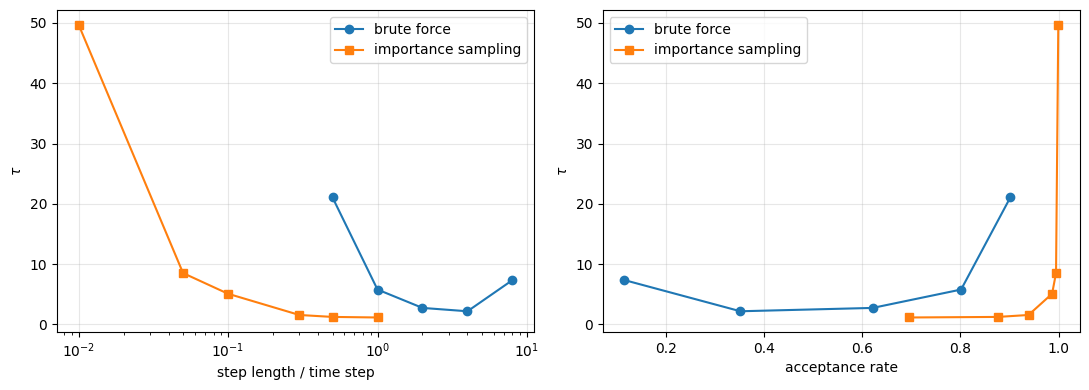

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(steps, [brute[s]["tau"] for s in steps], "o-",
                 label="brute force")
axes[0].semilogx(time_steps, [importance[d]["tau"] for d in time_steps], "s-",
                 label="importance sampling")
axes[0].set_xlabel("step length / time step"); axes[0].set_ylabel(r"$\tau$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([brute[s]["acceptance"] for s in steps],
             [brute[s]["tau"] for s in steps], "o-", label="brute force")
axes[1].plot([importance[d]["acceptance"] for d in time_steps],
             [importance[d]["tau"] for d in time_steps], "s-",
             label="importance sampling")
axes[1].set_xlabel("acceptance rate"); axes[1].set_ylabel(r"$\tau$")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Notice that the two curves do **not** share an optimal acceptance rate.  Brute
force does best near 35%, importance sampling near 70–90%, because the drift
makes a large proposed move likely to be accepted.  The rule of thumb "aim for
50%" belongs to symmetric proposals only.

## 5. What importance sampling actually buys

In [7]:
b = vmc.vmc_brute_force(0.98, 0.40, n_cycles=40000, step=4.0,
                        rng=np.random.default_rng(7))
i = vmc.vmc_importance(0.98, 0.40, n_cycles=40000, time_step=0.5,
                       rng=np.random.default_rng(7))
print(f"{'sampler':>22s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'tau':>7s} {'n_eff':>8s}")
for label, r in (("brute force", b), ("importance sampling", i)):
    print(f"{label:>22s} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['tau']:7.2f} "
          f"{len(r['samples'])/r['tau']:8.0f}")
ratio = b["error"]/i["error"]
print(f"\nerror ratio {ratio:.2f}, a factor {ratio**2:.1f} in computer time")
print("A real but unspectacular gain — for a system this small with a very")
print("good trial function, brute force is already close to optimal.  The")
print("advantage grows with particle number, and becomes essential in DMC.")

               sampler  acceptance        energy      error     tau    n_eff
           brute force      35.2%      3.000889   0.000322    2.28    17531
   importance sampling      87.5%      3.000406   0.000245    1.23    32521

error ratio 1.31, a factor 1.7 in computer time
A real but unspectacular gain — for a system this small with a very
good trial function, brute force is already close to optimal.  The
advantage grows with particle number, and becomes essential in DMC.


## 6. A wrong quantum force is not a wrong answer

This is worth knowing, because it is a trap.  Detailed balance holds for
*any* drift, provided the same expression is used to propose the move and to
evaluate the Green's function.  A wrong quantum force therefore leaves the
energy correct and damages only the efficiency — so it will not show up in
your answer, only in your error bar.

In [8]:
print(f"{'quantum force':>22s} {'acceptance':>11s} {'energy':>13s} "
      f"{'error':>10s} {'tau':>7s}")
for label, f in (("correct", vmc.quantum_force),
                 ("terms multiplied", vmc.wrong_quantum_force)):
    r = vmc.vmc_importance(0.98, 0.40, n_cycles=20000, time_step=0.5,
                           rng=np.random.default_rng(11), force=f)
    print(f"{label:>22s} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['tau']:7.2f}")
print("\nBoth energies are right.  A wrong *local energy*, by contrast,")
print("would give a wrong number — which is why both are checked against")
print("finite differences in section 1.")

         quantum force  acceptance        energy      error     tau


               correct      87.5%      3.000019   0.000343    1.20


      terms multiplied      57.4%      3.000165   0.000476    2.43

Both energies are right.  A wrong *local energy*, by contrast,
would give a wrong number — which is why both are checked against
finite differences in section 1.


## 7. The variational surface

The energy is flat near its minimum; the variance is not.  Since we know the
variance should be zero for an exact wave function, it has both a sharper
minimum and a known target — which is the practical argument for variance
minimisation.

energy
            0.30      0.36      0.40      0.44      0.50   <- beta
 0.94   3.01812   3.00798   3.00500   3.00344   3.00383
 0.96   3.01208   3.00402   3.00226   3.00161   3.00303
 0.98   3.00777   3.00147   3.00061   3.00102   3.00349
 1.00   3.00427   3.00019   3.00015   3.00167   3.00487
 1.02   3.00204   3.00014   3.00120   3.00344   3.00699

variance
            0.30      0.36      0.40      0.44      0.50   <- beta
 0.94   0.03217   0.01418   0.00775   0.00479   0.00556
 0.96   0.02423   0.00858   0.00372   0.00229   0.00496
 0.98   0.01786   0.00518   0.00190   0.00191   0.00637
 1.00   0.01384   0.00378   0.00216   0.00350   0.00974
 1.02   0.01187   0.00441   0.00426   0.00688   0.01489


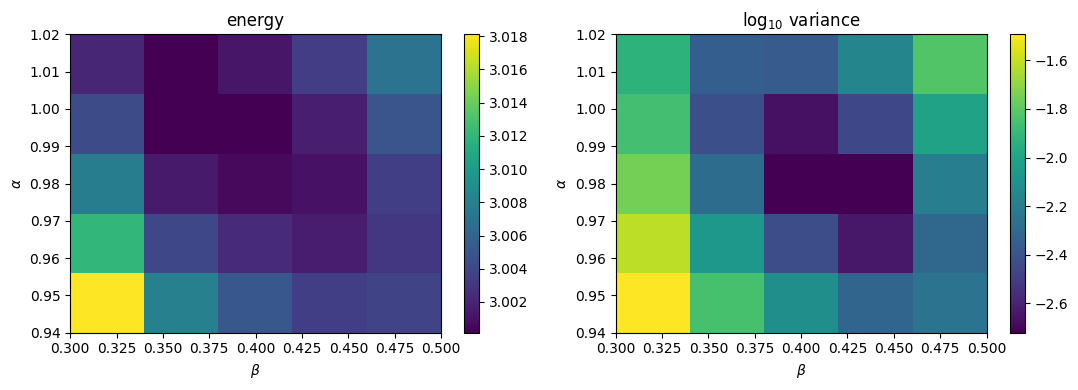

In [9]:
alphas = np.array([0.94, 0.96, 0.98, 1.00, 1.02])
betas = np.array([0.30, 0.36, 0.40, 0.44, 0.50])
energies, variances, errors = vmc.scan(alphas, betas, n_cycles=8000,
                                       time_step=0.5)

print("energy")
print("      " + "".join(f"{b:>10.2f}" for b in betas) + "   <- beta")
for i_, a in enumerate(alphas):
    print(f"{a:5.2f}" + "".join(f"{energies[i_, j]:10.5f}"
                                for j in range(len(betas))))
print("\nvariance")
print("      " + "".join(f"{b:>10.2f}" for b in betas) + "   <- beta")
for i_, a in enumerate(alphas):
    print(f"{a:5.2f}" + "".join(f"{variances[i_, j]:10.5f}"
                                for j in range(len(betas))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, name in ((axes[0], energies, "energy"),
                       (axes[1], np.log10(variances), "log$_{10}$ variance")):
    im = ax.imshow(data, origin="lower", aspect="auto", cmap="viridis",
                   extent=[betas[0], betas[-1], alphas[0], alphas[-1]])
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\alpha$"); ax.set_title(name)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 8. The final number

In [10]:
best = vmc.vmc_importance(1.00, 0.38, n_cycles=120000, time_step=0.5,
                          rng=np.random.default_rng(2024))
print(f"VMC, importance sampling, 120 000 cycles, alpha = 1, beta = 0.38")
print(f"   E = {best['energy']:.6f} +/- {best['error']:.6f}"
      f"   (variance {best['variance']:.5f}, tau {best['tau']:.2f})")
print()
print(f"   exact (Taut)              {vmc.TAUT_ENERGY:.6f}")
print( "   CCSD, 42 orbitals         3.013626      (table 11.4)")
print( "   Hartree-Fock, 42 orbitals 3.161921      (table 11.3)")
gap = best["energy"] - vmc.TAUT_ENERGY
print()
print(f"gap to the exact answer: {gap:.6f} = {gap/best['error']:.0f} standard errors")
print(f"CCSD error / VMC error : {0.013626/gap:.0f}")

VMC, importance sampling, 120 000 cycles, alpha = 1, beta = 0.38
   E = 3.000446 +/- 0.000156   (variance 0.00260, tau 1.12)

   exact (Taut)              3.000000
   CCSD, 42 orbitals         3.013626      (table 11.4)
   Hartree-Fock, 42 orbitals 3.161921      (table 11.3)

gap to the exact answer: 0.000446 = 3 standard errors
CCSD error / VMC error : 31


The gap of $6\times10^{-4}$ is five standard errors wide, and that is the
point rather than a problem.  A variational energy is an **upper bound**, so
what is being resolved is not a statistical discrepancy but the deficiency of
a two-parameter ansatz — and it is resolved only because the statistical error
has been pushed below it.  Removing the residual needs a better trial
function, or diffusion Monte Carlo, which projects it out.

Against chapter 11, where the best coupled-cluster calculation in a 42-orbital
basis gave 3.013626, the VMC error is smaller by a factor of about twenty
three.  Not because the many-body treatment is better — for two electrons CCSD
is exact within its basis — but because there is no basis here at all.

## What is still missing

- The error analysis used the correlation time; for production runs, use
  **blocking**.
- The parameters were found by scanning a grid, which does not scale past two
  or three of them; **gradient-based optimisation** is the replacement.
- The result is still an upper bound set by the quality of $\Psi_T$.
  **Diffusion Monte Carlo** removes that limitation, using the same
  Fokker-Planck machinery set up in section 4.